# Importações das bibliotecas utilizadas no projeto.

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import re
import os

Para lógica do detector de phishing:
- Preparar o dataset (upload de CSV ou JSON, seguindo a estrutura de Email Text e Email Type);
- Pre-processamento do dataset: Padronizar e limpar colunas do dataset
- Normalização do Email Text
- Carregamento do dataset processado
- Treinamento baseado no Naive Bayes Multinomial
- Predição

Para iniciar o pré-processamento do dataset, criamos a função de limpar os textos presentes no arquivo enviado na pasta `/datasets`

In [47]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", "", text)

    return text

# Pre-processamento e padronização das colunas:

Para isso, foi criado dois arrays que trazem: 
- Labels válidas para classificação dos emails:
    - *Nota*: No dataset do Hugging Face, as classes são SAFE EMAIL e PHISHING EMAIL, mas como é permitido usar também formato .json, o usuário pode adicionar outro valor para a coluna de label;
- Mapeamento das labels para validar com o modelo
- Colunas obrigatórias, que no caso, vai servir como base.

## Explorando o Load

Inicialmente ele carrega o dataset dentro da pasta especificada. Como permite dois tipos de arquivos (.json, .csv), ele verifica a extensão do arquivo antes de prosseguir e mostra as colunas inicialmente desses arquivos. 

Faz o processo de tornar minúsculo e renomear as colunas iniciais do dataset, que são Email Text e Email Type, para respectivamente, body e label.

### Processamento das colunas

```py
    # processar as colunas
    df["body"] = (
        df["body"]
        .fillna("")
        .astype(str)
    )

    df["label"] = (
        df["label"]
        .astype(str)
        .str.lower()
        .map(LABEL_MAPPING)
    )

    # cria a coluna de text no data processed a partir do body processado e limpo
    df["text"] = (
        df["body"]
        .apply(clean_text)
    )
```

### Salvamento do dataset processado

Antes disso, verifica se o diretório ``processed`` existe, se não, cria e transforma os dados processados em um arquivo .CSV.

```py
# salvar o dataset processado
    output_dir = os.path.join("..", "datasets", "processed")

    os.makedirs(output_dir, exist_ok=True)

    df.to_csv(
        os.path.join(output_dir, "processed_emails.csv"),
        index=False
    )
```

In [46]:
VALID_LABELS = [
    "safe",
    "spam",
    "phishing"
]

# pra dataset customizado, label chave:valor e adiciona aqui, a possibilidade de ser do tipo SPAM ao inves de só phising
LABEL_MAPPING = {
    "ham": "safe",
    "safe": "safe",
    "safe email": "safe",
    "legitimate": "safe",
    "spam": "spam",
    "phishing": "phishing",
    "phishing email": "phishing"
}

REQUIRED_COLUMNS = [
    "body",
    "label"
]

def load_dataset(path: str):
    # carregamento do dataset
    if path.endswith(".csv"):
        df = pd.read_csv(
            path,
            encoding="utf-8"
        )

    elif path.endswith(".json"):
        df = pd.read_json(path)

    else:
        raise ValueError(
            "Formato inválido"
        )

    if df.empty:
        raise ValueError(
            "Dataset vazio"
        )
    print(df.columns.tolist())

# pega as colunas do csv e deixa tudo minusculo
    df.columns = [
        column.strip().lower()
        for column in df.columns
    ]
    print("Colunas encontradas do CSV / Json:")
    print(df.columns.tolist())

    df = df.rename(columns={
        "email text": "body",
        "email type": "label"
    })
    print("Renomear aplicado:")
    print(df.columns.tolist())

    for column in REQUIRED_COLUMNS:
        if column not in df.columns:
            raise ValueError(
                f"Coluna ausente: {column}"
            )

    # processar as colunas
    df["body"] = (
        df["body"]
        .fillna("")
        .astype(str)
    )

    df["label"] = (
        df["label"]
        .astype(str)
        .str.lower()
        .map(LABEL_MAPPING)
    )

    # cria a coluna de text no data processed a partir do body processado e limpo
    df["text"] = (
        df["body"]
        .apply(clean_text)
    )

    invalid_labels = df[
        ~df["label"].isin(VALID_LABELS)
    ]

    if not invalid_labels.empty:
        print()
        print("Labels inválidas encontradas:")
        print(invalid_labels["label"].unique())

        raise ValueError(
            "Labels inválidas encontradas"
        )
    
    # salvar o dataset processado
    output_dir = os.path.join("..", "datasets", "processed")

    os.makedirs(output_dir, exist_ok=True)

    df.to_csv(
        os.path.join(output_dir, "processed_emails.csv"),
        index=False
    )
    return df

# Visualizar o conteúdo presente após limpar:

Ele deve transformar o Email Text e Email Type respectivamente para body, label (email type processado) e text (limpo).

In [45]:
output_path = os.path.join("..", "datasets", "processed", "processed_emails.csv")

df = pd.read_csv(output_path)
df.to_csv(output_path, index=False)

loaded_df = pd.read_csv(output_path)

loaded_df.head()

,unnamed: 0,body,label,text
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",safe,re disc uniformitarianism re sex la...
1,1,the other side of * galicismos * * galicismo *...,safe,the other side of galicismos galicismo is ...
2,2,re : equistar deal tickets are you still avail...,safe,re equistar deal tickets are you still availa...
3,3,\nHello I am your hot lil horny toy.\n I am...,phishing,\nhello i am your hot lil horny toy\n i am ...
4,4,software at incredibly low prices ( 86 % lower...,phishing,software at incredibly low prices lower d...


# Visualizar distribuição da quantidade de emails com labelling SAFE e PHISHING:

['Unnamed: 0', 'Email Text', 'Email Type']
Colunas encontradas do CSV / Json:
['unnamed: 0', 'email text', 'email type']
Renomear aplicado:
['unnamed: 0', 'body', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   unnamed: 0  18650 non-null  int64 
 1   body        18650 non-null  object
 2   label       18650 non-null  object
 3   text        18650 non-null  object
dtypes: int64(1), object(3)
memory usage: 582.9+ KB


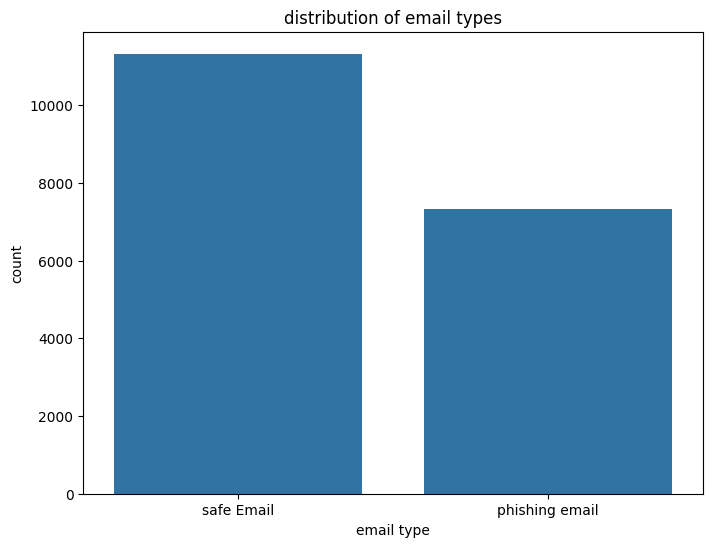

In [44]:
def visualizar_dataset_info(dataset_path: str):
    df = load_dataset(dataset_path)

    df = df.dropna(subset=['body'])
    df.info()
    
    email_type_counts = df['label'].value_counts()

    plt.figure(figsize=(8, 6))
    sns.barplot(x=email_type_counts.index, y=email_type_counts.values)
    plt.xticks(ticks=[0, 1], labels=['safe Email', 'phishing email'])
    plt.title('distribution of email types')
    plt.xlabel('email type')
    plt.ylabel('count')
    plt.show()
    
visualizar_dataset_info("../datasets/Phishing_Email.csv")

# Train Model

- Carrega o dataset tratado
- Separa text e label (tipo de email)
- Uso do vetorizador TF-IDF para transformar as palavras em números
- O `X_vectorized` vai transformar esses números em uma vetores

## A partir daqui,

O train_test_split divide os dados entre teste e treino.

### Elementos pra entender:
- test_size=0.2 indica a porcentagem que vai pra teste (20%)
- random_state=42 - Faz a divisão ser reproduzível.
- stratify é equilibrio da proporção das classes, deixando que a proporção que tem do dataset ser mais de um tipo do que outro, se manter.



In [48]:
def train_model(dataset_path: str):
    df = load_dataset(dataset_path)

    X = df["body"]
    y = df["label"]

    vectorizer = TfidfVectorizer()

    X_vectorized = vectorizer.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_vectorized,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = MultinomialNB()

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print(classification_report(y_test, predictions))

    joblib.dump(model, os.path.join("..", "models", "model.pkl"))
    joblib.dump(vectorizer, os.path.join("..", "models", "vectorizer.pkl"))
    print("Modelo treinado e salvo + vectorizer")

# Sobre o Modelo

O modelo utilizado aqui é o Naive Bayes Multinomial, que ele aprende padrões.

O `model.fit` basicamente entende os textos usados em emails (variáveis independentes, o X) e as respostas que o modelo deve aprender a partir disso (variável dependente, o Y).

Nesse caso,
Para saber a label (Y_train), preciso saber o que contém no email: body e subject. Partes do email que possa identificar como SAFE, SPAM ou PHISHING.

In [49]:
def predict_email(text: str):
    model = joblib.load(os.path.join("..", "models", "model.pkl"))

    vectorizer = joblib.load(os.path.join("..", "models", "vectorizer.pkl"))

    print("Texto digitado pelo usuário: ", text)
    text = clean_text(text)

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)

    print()
    print("Resultado:")
    print(prediction[0])

# CLI para interação:

In [54]:
while True:
    print()
    print("1 - Train")
    print("2 - Predict")
    print("3 - Exit")

    option = input("> ")
    
    if option == "1":
        train_model("../datasets/Phishing_Email.csv")

    elif option == "2":
        text = input("Email: ")

        predict_email(text)

    elif option == "3":
        break
    else:
        print("Opcao invalida")


1 - Train
2 - Predict
3 - Exit
['Unnamed: 0', 'Email Text', 'Email Type']
Colunas encontradas do CSV / Json:
['unnamed: 0', 'email text', 'email type']
Renomear aplicado:
['unnamed: 0', 'body', 'label']
              precision    recall  f1-score   support

    phishing       0.97      0.78      0.87      1466
        safe       0.88      0.98      0.93      2264

    accuracy                           0.91      3730
   macro avg       0.92      0.88      0.90      3730
weighted avg       0.91      0.91      0.90      3730

Modelo treinado e salvo + vectorizer

1 - Train
2 - Predict
3 - Exit
Texto digitado pelo usuário:  hot

Resultado:
phishing

1 - Train
2 - Predict
3 - Exit
Opcao invalida

1 - Train
2 - Predict
3 - Exit
Texto digitado pelo usuário:  lots of money

Resultado:
phishing

1 - Train
2 - Predict
3 - Exit
Texto digitado pelo usuário:  digital bearer

Resultado:
safe

1 - Train
2 - Predict
3 - Exit


# Modelo de tratamento em JSON

In [53]:
while True:
    print()
    print("------ DETECTOR DE PHISHING MAIORAL ------")
    print("1 - Train")
    print("2 - Predict")
    print("3 - Exit")

    option = input("> ")
    
    if option == "1":
        train_model("../datasets/Phishing_Email.json")

    elif option == "2":
        text = input("Escreva o texto do email que quer identificar: ")

        predict_email(text)

    elif option == "3":
        break
    else:
        print("Opcao invalida. Tente novamente.")


1 - Train
2 - Predict
3 - Exit
              precision    recall  f1-score   support

    phishing       1.00      0.72      0.84      1296
        safe       0.86      1.00      0.92      2137

    accuracy                           0.90      3433
   macro avg       0.93      0.86      0.88      3433
weighted avg       0.91      0.90      0.89      3433


1 - Train
2 - Predict
3 - Exit

Resultado:
phishing

1 - Train
2 - Predict
3 - Exit
